# Human leader/follower behavior by collaborating agent

This notebook reads `main_phase(2).csv`, classifies movement actions as leader/follower/neutral, and plots the **human participant's movement behavior while collaborating with each named agent**.

Important: the preset `lambda` from the task code is used only for plot labels and ordering. The x-axis labels include each collaborating agent's name, role, preset λ, and λ direction. The bar heights are calculated from human movement behavior during that collaboration:

`leader / (leader + follower)`

No CSVs or figures are saved by this notebook; outputs are only displayed in the notebook.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

INPUT_CSV = Path("main_phase(2).csv")

# These are the preset agent parameters from main_phase.js.
# They are used only for plot labels and sorting, NOT for calculating behavior.
# Convention:
#   negative lambda = follower-preset agent
#   positive lambda = leader-preset agent
#   zero lambda     = neutral-preset agent
AGENT_INFO = {
    "Tom":   {"case": 1, "role": "security", "level": "high", "lambda": 0.00},
    "Jerry": {"case": 2, "role": "forager",  "level": "high", "lambda": 0.00},
    "Cindy": {"case": 3, "role": "security", "level": "med",  "lambda": -0.75},
    "Frank": {"case": 4, "role": "forager",  "level": "med",  "lambda": 0.40},
    "Alice": {"case": 5, "role": "security", "level": "low",  "lambda": 0.40},
    "Grace": {"case": 6, "role": "forager",  "level": "low",  "lambda": -0.75},
}

AGENT_ORDER = list(AGENT_INFO.keys())
AGENT_LAMBDA = {name: info["lambda"] for name, info in AGENT_INFO.items()}
AGENT_ROLE = {name: info["role"] for name, info in AGENT_INFO.items()}
AGENT_LEVEL = {name: info["level"] for name, info in AGENT_INFO.items()}
AGENT_CASE = {name: info["case"] for name, info in AGENT_INFO.items()}

# Main plotted behavior metric.
# This is calculated from HUMAN movement rows while collaborating with each agent:
# leader / (leader + follower), averaged across participants.
PLOT_METRIC = "leader_share_lf_only"
CHANCE_VALUE = 0.5
ALPHA = 0.05

if not INPUT_CSV.exists():
    candidates = sorted(Path(".").glob("main_phase*.csv"))
    if not candidates:
        raise FileNotFoundError("No main_phase CSV found in this folder.")
    INPUT_CSV = candidates[0]

print("Reading:", INPUT_CSV)
df = pd.read_csv(INPUT_CSV)
print("Rows:", len(df), "Columns:", len(df.columns))
df.head()

Reading: main_phase.csv
Rows: 9312 Columns: 70


,source_file,participant_id,main_row_index,iso_time,iso_time_parsed,phase,event_type,event_name,action_clean,actor_type,role,action,is_role_action,is_human_action,is_agent_action,success_bool,rt_ms,rt_sec,phase_index,key,repetition,round,turn_global,turn_index_in_round,move_index_in_turn,current_x,current_y,from_x,from_y,to_x,to_y,dx,dy,clamped,success,reason,forager_x,forager_y,security_x,security_y,forager_stun_turns,gold_total,gold_delta,tile_gold_mine,tile_mine_type,tile_x,tile_y,depletion_status,chase_status,alien_id,alien_x,alien_y,has_alien,chased_away,found_alien_count,found_alien_id,scan_center_x,scan_center_y,scanned_tile_count,map_name,map_reward_level,map_risk_level,map_num,partner_name,partner_role,human_role,decay_prob,mine_type_key,mine_type_raw,rng_u
0,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,1,2026-05-12T03:37:10.178Z,2026-05-12 03:37:10.178000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,6208.0,6.208,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,2,2026-05-12T03:37:12.995Z,2026-05-12 03:37:12.995000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,2816.0,2.816,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,3,2026-05-12T03:37:16.268Z,2026-05-12 03:37:16.268000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,3274.0,3.274,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,4,2026-05-12T03:37:18.018Z,2026-05-12 03:37:18.018000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,1750.0,1.750,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,5,2026-05-12T03:38:52.266Z,2026-05-12 03:38:52.266000+00:00,main,phase_event,game_start,game_start,NaN,NaN,NaN,False,False,False,False,94248.0,94.248,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Classify movement rows

For every movement action, the notebook compares the mover's Manhattan distance to the other role before and after the move.

- distance increases = leader move
- distance decreases = follower move
- distance unchanged = neutral move
- no actual position change = excluded from the main summary


In [2]:
move_actions = {"move_up", "move_down", "move_left", "move_right"}

moves = df[
    df["action_clean"].isin(move_actions)
    & df["event_name"].eq("move")
    & df["partner_name"].notna()
].copy()

needed_cols = [
    "participant_id", "partner_name", "actor_type", "role",
    "from_x", "from_y", "to_x", "to_y",
    "forager_x", "forager_y", "security_x", "security_y",
]
missing = [c for c in needed_cols if c not in moves.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

moves = moves.dropna(subset=needed_cols).copy()

# The moving role is in `role`.
# If forager moved, the other role is security; if security moved, the other role is forager.
moves["other_role"] = np.where(moves["role"].eq("forager"), "security", "forager")
moves["other_x"] = np.where(moves["role"].eq("forager"), moves["security_x"], moves["forager_x"])
moves["other_y"] = np.where(moves["role"].eq("forager"), moves["security_y"], moves["forager_y"])

moves["distance_before"] = (moves["from_x"] - moves["other_x"]).abs() + (moves["from_y"] - moves["other_y"]).abs()
moves["distance_after"] = (moves["to_x"] - moves["other_x"]).abs() + (moves["to_y"] - moves["other_y"]).abs()
moves["distance_change"] = moves["distance_after"] - moves["distance_before"]

moves["changed_position"] = (moves["from_x"].ne(moves["to_x"])) | (moves["from_y"].ne(moves["to_y"]))

moves["movement_label"] = np.select(
    [
        ~moves["changed_position"],
        moves["distance_change"].gt(0),
        moves["distance_change"].lt(0),
        moves["distance_change"].eq(0),
    ],
    ["no_position_change", "leader", "follower", "neutral"],
    default="unknown",
)

print("Classified move rows:", len(moves))
print(moves["movement_label"].value_counts(dropna=False))
moves.head()

Classified move rows: 6539
movement_label
leader                3406
follower              3129
no_position_change       4
Name: count, dtype: int64


,source_file,participant_id,main_row_index,iso_time,iso_time_parsed,phase,event_type,event_name,action_clean,actor_type,role,action,is_role_action,is_human_action,is_agent_action,success_bool,rt_ms,rt_sec,phase_index,key,repetition,round,turn_global,turn_index_in_round,move_index_in_turn,current_x,current_y,from_x,from_y,to_x,to_y,dx,dy,clamped,success,reason,forager_x,forager_y,security_x,security_y,forager_stun_turns,gold_total,gold_delta,tile_gold_mine,tile_mine_type,tile_x,tile_y,depletion_status,chase_status,alien_id,alien_x,alien_y,has_alien,chased_away,found_alien_count,found_alien_id,scan_center_x,scan_center_y,scanned_tile_count,map_name,map_reward_level,map_risk_level,map_num,partner_name,partner_role,human_role,decay_prob,mine_type_key,mine_type_raw,rng_u,other_role,other_x,other_y,distance_before,distance_after,distance_change,changed_position,movement_label
46,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,47,2026-05-12T03:47:39.791Z,2026-05-12 03:47:39.791000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,6044.0,6.044,1.0,ArrowLeft,1.0,1.0,NaN,NaN,1.0,5.0,6.0,6.0,6.0,5.0,6.0,-1.0,0.0,0.0,NaN,NaN,6.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,0.0,1.0,1.0,True,leader
47,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,48,2026-05-12T03:47:43.183Z,2026-05-12 03:47:43.183000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,3392.0,3.392,1.0,ArrowLeft,1.0,1.0,NaN,NaN,2.0,4.0,6.0,5.0,6.0,4.0,6.0,-1.0,0.0,0.0,NaN,NaN,5.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,1.0,2.0,1.0,True,leader
48,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,49,2026-05-12T03:47:47.798Z,2026-05-12 03:47:47.798000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,4615.0,4.615,1.0,ArrowLeft,1.0,1.0,NaN,NaN,3.0,3.0,6.0,4.0,6.0,3.0,6.0,-1.0,0.0,0.0,NaN,NaN,4.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,2.0,3.0,1.0,True,leader
49,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,50,2026-05-12T03:47:48.072Z,2026-05-12 03:47:48.072000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,274.0,0.274,1.0,ArrowLeft,1.0,1.0,NaN,NaN,4.0,2.0,6.0,3.0,6.0,2.0,6.0,-1.0,0.0,0.0,NaN,NaN,3.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,3.0,4.0,1.0,True,leader
50,gridgame_clean_Bill_2026-05-12T04-39-47-530Z.csv,Bill,51,2026-05-12T03:47:48.534Z,2026-05-12 03:47:48.534000+00:00,main,role_action,move,move_left,human,forager,move_left,True,True,False,False,462.0,0.462,1.0,ArrowLeft,1.0,1.0,NaN,NaN,5.0,1.0,6.0,2.0,6.0,1.0,6.0,-1.0,0.0,0.0,NaN,NaN,2.0,6.0,6.0,6.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_reward_low_risk_01.csv,low,low,1.0,Alice,security,forager,NaN,NaN,NaN,NaN,security,6.0,6.0,4.0,5.0,1.0,True,leader


## Summarize human behavior per participant × collaborating agent

This part uses only moves made by the human participant (`actor_type == "human"`).

Each bar is grouped by `partner_name`, so the result means: **how the human moved when collaborating with that agent**.

The preset \(\lambda\) values are merged afterward only for labeling.


In [3]:
def summarize_movement(data, group_cols):
    out = (
        data.groupby(group_cols + ["movement_label"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for col in ["leader", "follower", "neutral", "no_position_change"]:
        if col not in out.columns:
            out[col] = 0

    out = out.rename(columns={
        "leader": "leader_count",
        "follower": "follower_count",
        "neutral": "neutral_count",
        "no_position_change": "no_position_change_count",
    })

    out["valid_move_count"] = out["leader_count"] + out["follower_count"] + out["neutral_count"]
    out["leader_follower_count"] = out["leader_count"] + out["follower_count"]

    out["leader_follower_ratio"] = np.where(
        out["follower_count"].gt(0),
        out["leader_count"] / out["follower_count"],
        np.nan,
    )
    out["leader_share_lf_only"] = np.where(
        out["leader_follower_count"].gt(0),
        out["leader_count"] / out["leader_follower_count"],
        np.nan,
    )
    out["follower_share_lf_only"] = np.where(
        out["leader_follower_count"].gt(0),
        out["follower_count"] / out["leader_follower_count"],
        np.nan,
    )
    out["leader_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["leader_count"] / out["valid_move_count"],
        np.nan,
    )
    out["follower_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["follower_count"] / out["valid_move_count"],
        np.nan,
    )
    out["neutral_prop_all_valid_moves"] = np.where(
        out["valid_move_count"].gt(0),
        out["neutral_count"] / out["valid_move_count"],
        np.nan,
    )

    return out.sort_values(group_cols).reset_index(drop=True)

valid_moves = moves[moves["movement_label"].ne("no_position_change")].copy()

# IMPORTANT CHANGE:
# Use human movement rows, not agent movement rows.
# Grouping by partner_name gives the human behavior while collaborating with each agent.
human_moves = valid_moves[valid_moves["actor_type"].eq("human")].copy()

human_by_participant = summarize_movement(human_moves, ["participant_id", "partner_name", "role"])
human_by_participant = human_by_participant.rename(columns={"role": "human_role_during_collaboration"})
human_by_participant["collaborating_agent_role"] = human_by_participant["partner_name"].map(AGENT_ROLE)
human_by_participant["preset_lambda"] = human_by_participant["partner_name"].map(AGENT_LAMBDA)
human_by_participant["preset_lambda_direction"] = np.select(
    [
        human_by_participant["preset_lambda"].lt(0),
        human_by_participant["preset_lambda"].gt(0),
        human_by_participant["preset_lambda"].eq(0),
    ],
    ["follower", "leader", "neutral"],
    default="unknown",
)

print("Participant × collaborating-agent summary using HUMAN movement rows only:")
display(human_by_participant)


Participant × collaborating-agent summary using HUMAN movement rows only:


movement_label,participant_id,partner_name,human_role_during_collaboration,follower_count,leader_count,neutral_count,no_position_change_count,valid_move_count,leader_follower_count,leader_follower_ratio,leader_share_lf_only,follower_share_lf_only,leader_prop_all_valid_moves,follower_prop_all_valid_moves,neutral_prop_all_valid_moves,collaborating_agent_role,preset_lambda,preset_lambda_direction
0,Bill,Alice,forager,58,32,0,0,90,90,0.551724,0.355556,0.644444,0.355556,0.644444,0.0,security,0.40,leader
1,Bill,Cindy,forager,21,69,0,0,90,90,3.285714,0.766667,0.233333,0.766667,0.233333,0.0,security,-0.75,follower
2,Bill,Frank,security,100,33,0,0,133,133,0.330000,0.248120,0.751880,0.248120,0.751880,0.0,forager,0.40,leader
3,Bill,Grace,security,15,106,0,0,121,121,7.066667,0.876033,0.123967,0.876033,0.123967,0.0,forager,-0.75,follower
4,Bill,Jerry,security,83,55,0,0,138,138,0.662651,0.398551,0.601449,0.398551,0.601449,0.0,forager,0.00,neutral
5,Bill,Tom,forager,45,40,0,0,85,85,0.888889,0.470588,0.529412,0.470588,0.529412,0.0,security,0.00,neutral
6,Cici Zhang,Alice,forager,26,14,0,0,40,40,0.538462,0.350000,0.650000,0.350000,0.650000,0.0,security,0.40,leader
7,Cici Zhang,Cindy,forager,18,53,0,0,71,71,2.944444,0.746479,0.253521,0.746479,0.253521,0.0,security,-0.75,follower
8,Cici Zhang,Frank,security,66,30,0,0,96,96,0.454545,0.312500,0.687500,0.312500,0.687500,0.0,forager,0.40,leader
9,Cici Zhang,Grace,security,16,62,0,0,78,78,3.875000,0.794872,0.205128,0.794872,0.205128,0.0,forager,-0.75,follower


## Average across participants and test significance

For each collaborating agent, the notebook calculates the participant-average **human** behavior bar and tests whether the participant-level behavior measure differs from balance.

For the default behavior metric, the null value is 0.5.


In [4]:
def sem(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))

def one_sample_ttest(x, null_value=0.5):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean() if n else np.nan
    s = x.std(ddof=1) if n > 1 else np.nan
    se = s / np.sqrt(n) if n > 1 else np.nan

    if n < 2 or pd.isna(se) or se == 0:
        return pd.Series({"n": n, "mean": mean, "sem": se, "t": np.nan, "p": np.nan})

    if stats is not None:
        t, p = stats.ttest_1samp(x, popmean=null_value, nan_policy="omit")
    else:
        # Fallback: gives t but not an exact p-value if scipy is unavailable.
        t = (mean - null_value) / se
        p = np.nan

    return pd.Series({"n": n, "mean": mean, "sem": se, "t": t, "p": p})

def stars_from_p(p):
    if pd.isna(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

def lambda_direction(lam):
    if pd.isna(lam):
        return "unknown"
    if lam < 0:
        return "follower"
    if lam > 0:
        return "leader"
    return "neutral"

def label_for_agent(name):
    lam = AGENT_LAMBDA.get(name, np.nan)
    role = AGENT_ROLE.get(name, "unknown")
    role_label = role.capitalize()

    if pd.isna(lam):
        return f"{name}\n{role_label}\nλ=?"
    return f"{name}\n{role_label}\nλ={lam:+.2f}\n{lambda_direction(lam)}"

agent_stats = (
    human_by_participant
    .groupby("partner_name")[PLOT_METRIC]
    .apply(lambda x: one_sample_ttest(x, CHANCE_VALUE))
    .reset_index()
    .pivot(index="partner_name", columns="level_1", values=PLOT_METRIC)
    .reset_index()
)

# Add totals from the raw counts for context.
totals = (
    human_by_participant
    .groupby("partner_name")
    .agg(
        total_leader_count=("leader_count", "sum"),
        total_follower_count=("follower_count", "sum"),
        total_neutral_count=("neutral_count", "sum"),
        total_valid_move_count=("valid_move_count", "sum"),
        total_leader_follower_count=("leader_follower_count", "sum"),
    )
    .reset_index()
)

tag = pd.DataFrame({
    "partner_name": AGENT_ORDER,
    "agent_case": [AGENT_CASE[n] for n in AGENT_ORDER],
    "agent_role_from_code": [AGENT_ROLE[n] for n in AGENT_ORDER],
    "agent_level_from_code": [AGENT_LEVEL[n] for n in AGENT_ORDER],
    "preset_lambda": [AGENT_LAMBDA[n] for n in AGENT_ORDER],
})
tag["preset_lambda_direction"] = tag["preset_lambda"].map(lambda_direction)

agent_stats = agent_stats.merge(totals, on="partner_name", how="left").merge(tag, on="partner_name", how="right")
agent_stats["significance"] = agent_stats["p"].map(stars_from_p)
agent_stats["plot_label"] = agent_stats["partner_name"].map(label_for_agent)
agent_stats = agent_stats.sort_values("agent_case").reset_index(drop=True)

print("Human behavior by collaborating agent: average and significance:")
display(agent_stats[[
    "agent_case", "partner_name", "agent_role_from_code", "agent_level_from_code",
    "preset_lambda", "preset_lambda_direction",
    "n", "mean", "sem", "t", "p", "significance",
    "total_leader_count", "total_follower_count", "total_neutral_count", "total_valid_move_count"
]])

Human behavior by collaborating agent: average and significance:


,agent_case,partner_name,agent_role_from_code,agent_level_from_code,preset_lambda,preset_lambda_direction,n,mean,sem,t,p,significance,total_leader_count,total_follower_count,total_neutral_count,total_valid_move_count
0,1,Tom,security,high,0.00,neutral,5.0,0.446983,0.032003,-1.656651,0.172931,n.s.,177,221,0,398
1,2,Jerry,forager,high,0.00,neutral,5.0,0.310468,0.041440,-4.573595,0.010233,*,195,414,0,609
2,3,Cindy,security,med,-0.75,follower,5.0,0.717813,0.029414,7.405150,0.001774,**,327,130,0,457
3,4,Frank,forager,med,0.40,leader,5.0,0.253089,0.018907,-13.059539,0.000198,***,152,455,0,607
4,5,Alice,security,low,0.40,leader,5.0,0.330492,0.024520,-6.912932,0.002297,**,126,258,0,384
5,6,Grace,forager,low,-0.75,follower,5.0,0.744751,0.040588,6.030126,0.003812,**,411,144,0,555


## Bar plot: human leader/follower behavior when collaborating with each agent

The bars are observed participant-averaged **human** behavior. The x-axis labels show the collaborating agent name, role, preset \(\lambda\), and whether the preset is leader/follower/neutral.


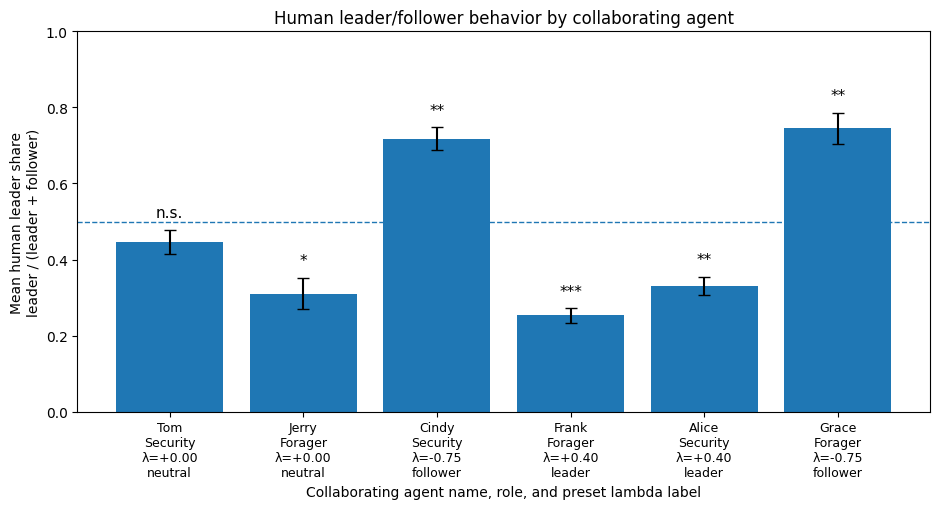

In [5]:
plot_df = agent_stats.copy()

x = np.arange(len(plot_df))
y = plot_df["mean"].astype(float).to_numpy()
yerr = plot_df["sem"].astype(float).to_numpy()

plt.figure(figsize=(9.5, 5.2))
plt.bar(x, y, yerr=yerr, capsize=4)
plt.axhline(CHANCE_VALUE, linestyle="--", linewidth=1)
plt.xticks(x, plot_df["plot_label"], rotation=0, fontsize=9)
plt.ylabel("Mean human leader share\nleader / (leader + follower)")
plt.xlabel("Collaborating agent name, role, and preset lambda label")
plt.title("Human leader/follower behavior by collaborating agent")
plt.ylim(0, max(1.0, np.nanmax(y + np.nan_to_num(yerr, nan=0)) + 0.08))

for xi, yi, se, sig in zip(x, y, yerr, plot_df["significance"]):
    offset = 0.025 if pd.isna(se) else se + 0.025
    plt.text(xi, yi + offset, sig, ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()


## Separate significance plot

This plot shows the statistical evidence for the human behavior while collaborating with each agent differing from balance. X-axis tick labels include each collaborating agent's role.

The dotted line is \(p = 0.05\). Values above the line are significant at the default threshold.


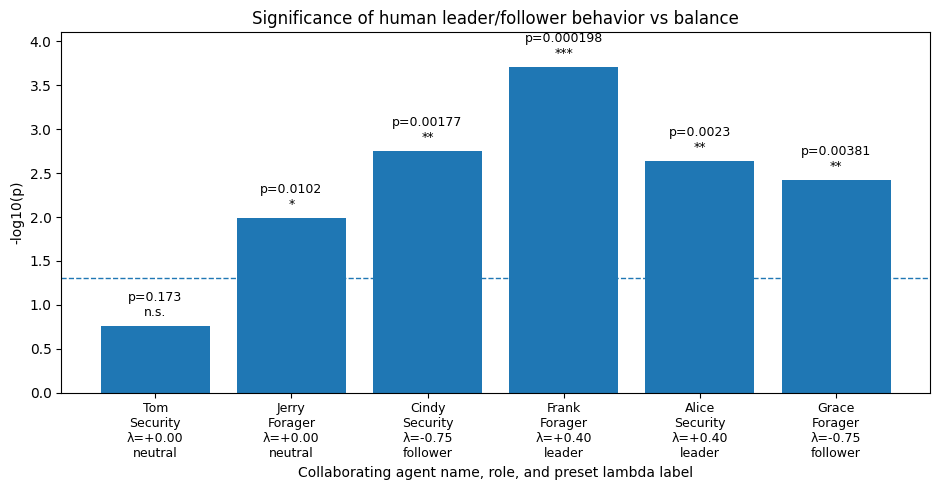

,partner_name,preset_lambda,mean,t,p,significance
0,Tom,0.00,0.446983,-1.656651,0.172931,n.s.
1,Jerry,0.00,0.310468,-4.573595,0.010233,*
2,Cindy,-0.75,0.717813,7.405150,0.001774,**
3,Frank,0.40,0.253089,-13.059539,0.000198,***
4,Alice,0.40,0.330492,-6.912932,0.002297,**
5,Grace,-0.75,0.744751,6.030126,0.003812,**


In [6]:
sig_df = agent_stats.copy()
sig_df["neg_log10_p"] = -np.log10(sig_df["p"].astype(float))
threshold = -np.log10(ALPHA)

x = np.arange(len(sig_df))
y = sig_df["neg_log10_p"].to_numpy()

plt.figure(figsize=(9.5, 5.0))
plt.bar(x, y)
plt.axhline(threshold, linestyle="--", linewidth=1)
plt.xticks(x, sig_df["plot_label"], rotation=0, fontsize=9)
plt.ylabel("-log10(p)")
plt.xlabel("Collaborating agent name, role, and preset lambda label")
plt.title("Significance of human leader/follower behavior vs balance")

finite_y = y[np.isfinite(y)]
ymax = max(threshold + 0.5, finite_y.max() + 0.4 if len(finite_y) else threshold + 0.5)
plt.ylim(0, ymax)

for xi, yi, p, sig in zip(x, y, sig_df["p"], sig_df["significance"]):
    if pd.isna(p):
        label = "p=n/a"
        ypos = threshold * 0.2
    else:
        label = f"p={p:.3g}\n{sig}"
        ypos = yi + 0.08
    plt.text(xi, ypos, label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

display(sig_df[["partner_name", "preset_lambda", "mean", "t", "p", "significance"]])


## Optional: participant-level plot

This plot shows each participant's human behavior value for each collaborating agent, with the agent-level mean overlaid.


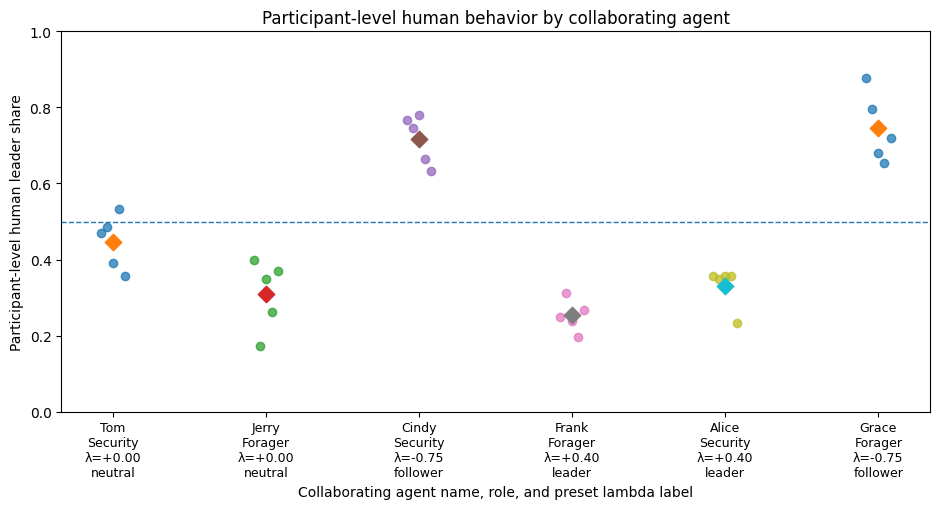

In [7]:
plot_points = human_by_participant.merge(agent_stats[["partner_name", "plot_label"]], on="partner_name", how="left")
order = agent_stats["partner_name"].tolist()
label_map = dict(zip(agent_stats["partner_name"], agent_stats["plot_label"]))

plt.figure(figsize=(9.5, 5.2))
for xi, name in enumerate(order):
    vals = plot_points.loc[plot_points["partner_name"].eq(name), PLOT_METRIC].dropna().astype(float).to_numpy()
    if len(vals):
        jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else np.array([0.0])
        plt.scatter(np.full(len(vals), xi) + jitter, vals, alpha=0.75)
        plt.scatter([xi], [agent_stats.loc[agent_stats["partner_name"].eq(name), "mean"].iloc[0]], marker="D", s=70)

plt.axhline(CHANCE_VALUE, linestyle="--", linewidth=1)
plt.xticks(np.arange(len(order)), [label_map[n] for n in order], rotation=0, fontsize=9)
plt.ylabel("Participant-level human leader share")
plt.xlabel("Collaborating agent name, role, and preset lambda label")
plt.title("Participant-level human behavior by collaborating agent")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
